In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kaggleanshita/resnet2/DAT-SEGREGATION/NONPD/Subject20_0.DAT_s1_003.png
/kaggle/input/datasets/kaggleanshita/resnet2/DAT-SEGREGATION/NONPD/4140_DATSCAN.png
/kaggle/input/datasets/kaggleanshita/resnet2/DAT-SEGREGATION/NONPD/152591_DATSCAN.png
/kaggle/input/datasets/kaggleanshita/resnet2/DAT-SEGREGATION/NONPD/130468_DATSCAN.png
/kaggle/input/datasets/kaggleanshita/resnet2/DAT-SEGREGATION/NONPD/Subject61_0.DAT_s2_004.png
/kaggle/input/datasets/kaggleanshita/resnet2/DAT-SEGREGATION/NONPD/178413_DATSCAN.png
/kaggle/input/datasets/kaggleanshita/resnet2/DAT-SEGREGATION/NONPD/111099_DATSCAN.png
/kaggle/input/datasets/kaggleanshita/resnet2/DAT-SEGREGATION/NONPD/4116_DATSCAN.png
/kaggle/input/datasets/kaggleanshita/resnet2/DAT-SEGREGATION/NONPD/Subject60_0.DAT_s1_007.png
/kaggle/input/datasets/kaggleanshita/resnet2/DAT-SEGREGATION/NONPD/3611_DATSCAN.png
/kaggle/input/datasets/kaggleanshita/resnet2/DAT-SEGREGATION/NONPD/115698_DATSCAN.png
/kaggle/input/datasets/kaggleanshita

In [4]:
# ============================================================
# DATA SPLIT
# ============================================================
import os, shutil, random

SRC_DIR  = "/kaggle/input/datasets/kaggleanshita/resnet2/DAT-SEGREGATION"
DEST_DIR = "/kaggle/working/ppmi-datscan-ntua-split"
TRAIN_RATIO = 0.8
SEED = 42

random.seed(SEED)

for cls in ["NONPD", "PD"]:
    src_cls = os.path.join(SRC_DIR, cls)
    files = os.listdir(src_cls)
    random.shuffle(files)

    split_idx = int(len(files) * TRAIN_RATIO)
    train_files = files[:split_idx]
    test_files = files[split_idx:]

    for f in train_files:
        os.makedirs(f"{DEST_DIR}/train/{cls}", exist_ok=True)
        shutil.copy(os.path.join(src_cls, f), os.path.join(DEST_DIR, "train", cls, f))

    for f in test_files:
        os.makedirs(f"{DEST_DIR}/test/{cls}", exist_ok=True)
        shutil.copy(os.path.join(src_cls, f), os.path.join(DEST_DIR, "test", cls, f))

print("✅ Train–Test split completed")

✅ Train–Test split completed


In [5]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision

from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
# ============================================================
# MIXED PRECISION + SEED
# ============================================================
mixed_precision.set_global_policy("mixed_float16")
tf.random.set_seed(42)
np.random.seed(42)


# ============================================================
# CONFIG
# ============================================================
BATCH_SIZE = 16
IMG_SIZE = (224, 224)
EPOCHS_STAGE1 = 100
EPOCHS_STAGE2 = 100
DATA_DIR = DEST_DIR

2026-02-26 18:11:32.440728: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772129492.595143      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772129492.638210      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772129492.987481      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772129492.987522      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772129492.987525      55 computation_placer.cc:177] computation placer alr

In [6]:
# ============================================================
# DATA GENERATORS
# ============================================================
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.12,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True
).flow_from_directory(
    f"{DATA_DIR}/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    f"{DATA_DIR}/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
NUM_CLASSES = len(class_names)

Found 1525 images belonging to 2 classes.
Found 383 images belonging to 2 classes.


In [7]:
# ============================================================
# APPLY SMOTE
# ============================================================
print("\nApplying SMOTE...")

X_train = []
y_train = []

for i in range(len(train_gen)):
    x_batch, y_batch = train_gen[i]
    X_train.append(x_batch)
    y_train.append(y_batch)

X_train = np.vstack(X_train)
y_train = np.vstack(y_train)

print("Before SMOTE:", np.sum(y_train, axis=0))

y_labels = np.argmax(y_train, axis=1)

# Flatten for SMOTE
n_samples = X_train.shape[0]
X_flat = X_train.reshape(n_samples, -1)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_flat, y_labels)

# Reshape back
X_res = X_res.reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 3)
y_res = tf.keras.utils.to_categorical(y_res, NUM_CLASSES)

print("After SMOTE:", np.sum(y_res, axis=0))


Applying SMOTE...
Before SMOTE: [ 356. 1169.]
After SMOTE: [1169. 1169.]


In [8]:
# ============================================================
# MODEL — ResNet50
# ============================================================
base = ResNet101(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)
model = models.Model(base.input, outputs)


I0000 00:00:1772129537.965069      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772129537.970796      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 43,841,154 (167.24 MB)

 Trainable params: 1,181,954 (4.51 MB)

 Non-trainable params: 42,659,200 (162.73 MB)

In [10]:
# ============================================================
# STAGE 1 TRAIN
# ============================================================
model.compile(
    optimizer=Adam(3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks = [
    EarlyStopping(monitor="loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="loss", patience=2, factor=0.5)
]

history_stage1 = model.fit(
    X_res, y_res,
    batch_size=BATCH_SIZE,
    validation_data=test_gen,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks,
    verbose=1
)
# ============================================================
# STAGE 2 FINE TUNE
# ============================================================
for layer in base.layers[-60:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history_stage2 = model.fit(
    X_res, y_res,
    batch_size=BATCH_SIZE,
    validation_data=test_gen,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


I0000 00:00:1772129559.596725     151 service.cc:152] XLA service 0x7dbf880a5c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772129559.596762     151 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772129559.596766     151 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772129563.154038     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/147 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.4896 - auc: 0.4018 - loss: 1.3047    

I0000 00:00:1772129571.365899     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.7388 - auc: 0.8017 - loss: 0.7156

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


147/147 ━━━━━━━━━━━━━━━━━━━━ 53s 193ms/step - accuracy: 0.7392 - auc: 0.8022 - loss: 0.7146 - val_accuracy: 0.6815 - val_auc: 0.7536 - val_loss: 0.8722 - learning_rate: 3.0000e-04
Epoch 2/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8519 - auc: 0.9325 - loss: 0.4163 - val_accuracy: 0.7755 - val_auc: 0.8507 - val_loss: 0.6318 - learning_rate: 3.0000e-04
Epoch 3/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8817 - auc: 0.9534 - loss: 0.3563 - val_accuracy: 0.7206 - val_auc: 0.8078 - val_loss: 0.7735 - learning_rate: 3.0000e-04
Epoch 4/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9014 - auc: 0.9678 - loss: 0.3047 - val_accuracy: 0.7755 - val_auc: 0.8725 - val_loss: 0.5901 - learning_rate: 3.0000e-04
Epoch 5/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9152 - auc: 0.9734 - loss: 0.2827 - val_accuracy: 0.8460 - val_auc: 0.9338 - val_loss: 0.4137 - learning_rate: 3.0000e-04
Epoch 6/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accu

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8654 - auc: 0.9226 - loss: 0.8551

Test Accuracy: 87.47%
Test AUC: 0.930
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 324ms/step
              precision    recall  f1-score   support

       NONPD       0.68      0.90      0.77        90
          PD       0.97      0.87      0.91       293

    accuracy                           0.87       383
   macro avg       0.82      0.88      0.84       383
weighted avg       0.90      0.87      0.88       383



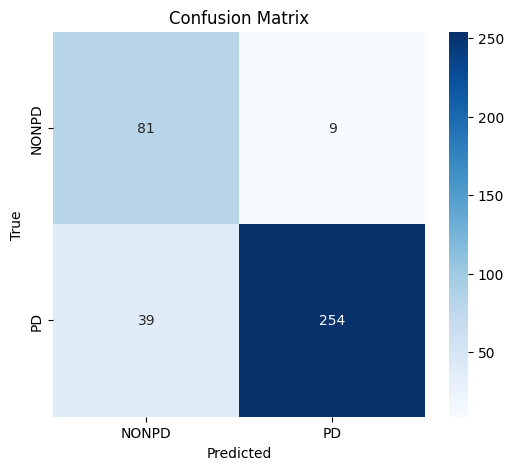

In [11]:


# ============================================================
# EVALUATION
# ============================================================
test_loss, test_acc, test_auc = model.evaluate(test_gen)

print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test AUC: {test_auc:.3f}")

y_probs = model.predict(test_gen)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_gen.classes

print(classification_report(y_true, y_pred, target_names=class_names))
# ============================================================
# DISPLAY RESULTS 
# ============================================================
cm = confusion_matrix(y_true, y_pred)
# ---------- CONFUSION MATRIX ----------
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

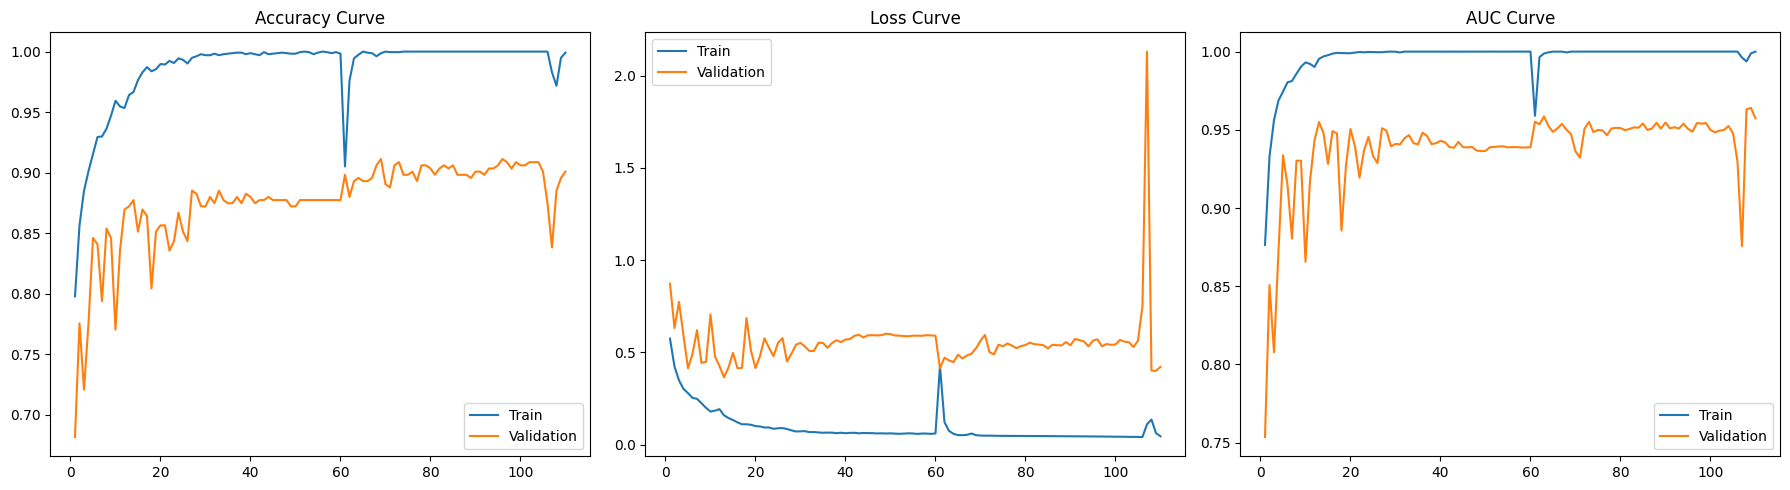

In [13]:
# ============================================================
# COMBINE HISTORIES
# ============================================================
history = {}
for key in history_stage1.history.keys():
    history[key] = history_stage1.history[key] + history_stage2.history[key]
# ---------- TRAINING GRAPHS ----------
epochs = range(1, len(history["accuracy"]) + 1)

plt.figure(figsize=(18,5))

# Accuracy
plt.subplot(1,3,1)
plt.plot(epochs, history["accuracy"], label="Train")
plt.plot(epochs, history["val_accuracy"], label="Validation")
plt.title("Accuracy Curve")
plt.legend()

# Loss
plt.subplot(1,3,2)
plt.plot(epochs, history["loss"], label="Train")
plt.plot(epochs, history["val_loss"], label="Validation")
plt.title("Loss Curve")
plt.legend()

# AUC
plt.subplot(1,3,3)
plt.plot(epochs, history["auc"], label="Train")
plt.plot(epochs, history["val_auc"], label="Validation")
plt.title("AUC Curve")
plt.legend()

plt.tight_layout()
plt.show()
# ============================================================
# SAVE RESULTS + ZIP
# ============================================================
import pandas as pd
import zipfile
os.makedirs("results", exist_ok=True)

# Predictions
pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred
}).to_csv("results/predictions.csv", index=False)

# Metrics
pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )
).transpose().to_csv("results/metrics.csv")

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
np.save("results/confusion_matrix.npy", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("results/confusion_matrix.png")
plt.close()

# Training Curves
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(history["accuracy"])
plt.plot(history["val_accuracy"])
plt.title("Accuracy")

plt.subplot(1,3,2)
plt.plot(history["loss"])
plt.plot(history["val_loss"])
plt.title("Loss")

plt.subplot(1,3,3)
plt.plot(history["auc"])
plt.plot(history["val_auc"])
plt.title("AUC")

plt.tight_layout()
plt.savefig("results/training_curves.png")
plt.close()

In [15]:
# Save model
model.save("results/resnet50_model.h5")

# ZIP creation
zip_path = "resnet101_results.zip"

with zipfile.ZipFile(zip_path, "w") as z:
    for root, dirs, files in os.walk("results"):
        for file in files:
            z.write(os.path.join(root, file))

print("✅ ZIP created")

from IPython.display import FileLink
display(FileLink(zip_path))

✅ ZIP created


/kaggle/working/resnet101_results.zip